## Part 1: Reliability Analysis of Accident Risk During Aircraft Landing

In [ ]:
"""
Part 1: Reliability Analysis of Accident Risk During Aircraft Landing
SYSEN 5200 Airport Operations Project

Corrected fault-tree structure for Path A (Wake Vortex Encounter).
The project description specifies that a trailing-aircraft separation
violation requires BOTH the pilot to be unable to adjust speed AND the
pilot to fail to communicate back to ATC: "If the pilot is unable to
communicate this problem back to the air traffic control unit on time,
this creates in-trail separation violation." E4 and E5 are therefore
modeled as an AND-gate sub-tree under M4. E1 and E6 are compound
conditional events whose probabilities are products of two Table-3 entries.

    M1  = AND( E0 , M7 , E11 )
    M7  = OR ( M3 , M4 )
    M3  = OR ( E1 , E2 , E3 )                          (ATC-caused)
    M4  = OR ( AND(E4, E5) , E6 )                      (Trailing-caused)
    E0  = Dangerous wake vortex exists
    E1  = P(ATC misidentifies) × P(misid → violation)  (compound)
    E2  = ATC misestimates wake / weather effects
    E3  = ATC instrument or comms error
    E4  = Pilot unable to adjust speed to target
    E5  = Pilot fails to communicate issue to ATC promptly
    E6  = P(go-around) × P(go-around → violation)      (compound)
    E11 = Detection / correction failure
"""
import numpy as np

# 1.1 WAKE VORTEX ENCOUNTER -------------------------------------------------

# Table 2 of project description: P(dangerous wake vortex | lead, trail)
# Rows = In-Trail (trailing), Columns = Lead aircraft
# Verified: Lead=Heavy, Trail=Small → 0.82 (problem statement example)
wv_table = {
    ('H','H'): 0.53, ('H','L'): 0.44, ('H','S'): 0.28,
    ('L','H'): 0.74, ('L','L'): 0.61, ('L','S'): 0.41,
    ('S','H'): 0.82, ('S','L'): 0.71, ('S','S'): 0.59,
}
P_SIZE = {'H': 0.33, 'L': 0.46, 'S': 0.21}

# E0 — Dangerous wake vortex exists (weather-independent, fleet-mix weighted)
P_E0 = sum(
    P_SIZE[lead] * P_SIZE[trail] * wv_table[(trail, lead)]
    for lead in 'HLS' for trail in 'HLS'
)
print(f"P(E0 — dangerous wake vortex) = {P_E0:.4f}")

# Project Table 3 — basic / basic-condition event probabilities (good, bad).
# Some basic events are conditional compounds (occurrence × leads-to-violation);
# we retain that interpretation as in the original data sheet.
events = {
    # E1 = ATC misidentifies aircraft type  →  causes violation
    'misid':          (2.69e-4, 2.69e-4),
    'misid_viol':     (3.82e-2, 3.82e-2),
    # E2 = ATC misestimates wake / weather effects
    'wx_misestimate': (5.19e-6, 2.33e-5),
    # E3 = ATC instrument or comms error
    'comm_fail':      (6.24e-5, 6.24e-5),
    # E4 = Pilot unable to adjust speed to target  →  causes violation
    'speed_fail':     (7.23e-4, 4.34e-3),
    'comm_back_fail': (1.17e-3, 1.17e-3),
    # E6 = Lead/trail conflict requires go-around  →  violates separation
    'go_around':      (1.57e-4, 4.71e-4),
    'go_around_viol': (2.01e-2, 2.01e-2),
    # E11 = Detection / correction failure
    'detect_fail':    (1.95e-3, 1.95e-3),
}


def or_exact(*probs):
    """
    Exact OR probability for independent events:
      P(A1 OR A2 OR ... An) = 1 - prod(1 - pi)
    Under conditional independence (given weather), this is exact.
    For rare events this is numerically close to the additive sum,
    but we use the exact formula for correctness.
    """
    result = 1.0
    for p in probs:
        result *= (1.0 - p)
    return 1.0 - result


def calc_WVE(ev_g, ev_b, P_E0=P_E0):
    """
    Corrected Path A fault-tree evaluation.

    M1 = AND( E0, M7, E11 )
    M7 = OR ( M3, M4 )
    M3 = OR ( E1, E2, E3 )
    M4 = OR ( AND(E4, E5), E6 )
    """
    results = {}
    for weather, ev in [('good', ev_g), ('bad', ev_b)]:
        # --- M3 : ATC-caused separation violation -------------------------
        P_E1 = ev['misid'] * ev['misid_viol']        # compound conditional event
        P_E2 = ev['wx_misestimate']
        P_E3 = ev['comm_fail']
        P_M3 = or_exact(P_E1, P_E2, P_E3)

        # --- M4 : Trailing-aircraft-caused separation violation -----------
        # Per project description, E4 and E5 must BOTH occur for violation:
        #   "If the pilot is unable to communicate this problem back to ATC
        #    on time, this creates in-trail separation violation."
        P_E4       = ev['speed_fail']                       # basic event
        P_E5       = ev['comm_back_fail']                   # basic event
        P_E4_AND_5 = P_E4 * P_E5                            # AND sub-gate
        P_E6       = ev['go_around'] * ev['go_around_viol'] # compound conditional event
        P_M4       = or_exact(P_E4_AND_5, P_E6)

        # --- M7 : In-trail separation violation ---------------------------
        P_M7 = or_exact(P_M3, P_M4)

        # --- M1 : Wake vortex encounter  = AND( E0, M7, E11 ) -------------
        P_E11 = ev['detect_fail']
        P_M1  = P_E0 * P_M7 * P_E11

        results[weather] = {
            'P_E1': P_E1, 'P_E2': P_E2, 'P_E3': P_E3,
            'P_E4': P_E4, 'P_E5': P_E5, 'P_E4_AND_5': P_E4_AND_5,
            'P_E6': P_E6,
            'P_M3': P_M3, 'P_M4': P_M4, 'P_M7': P_M7,
            'P_E11': P_E11, 'P_M1': P_M1,
        }
    return results


ev_g = {k: v[0] for k, v in events.items()}
ev_b = {k: v[1] for k, v in events.items()}
wve  = calc_WVE(ev_g, ev_b)

print("\n=== Path A — Wake Vortex Encounter (corrected fault tree) ===")
for weather in ['good', 'bad']:
    r = wve[weather]
    print(f"\n  {weather.capitalize()} Weather:")
    print(f"    E1  (ATC misid. compound)     = {r['P_E1']:.4e}")
    print(f"    E2  (Wx / wake misestimate)   = {r['P_E2']:.4e}")
    print(f"    E3  (ATC comms / instr.)      = {r['P_E3']:.4e}")
    print(f"    M3  (ATC OR E1,E2,E3)         = {r['P_M3']:.4e}")
    print(f"    E4  (Pilot speed fail)        = {r['P_E4']:.4e}")
    print(f"    E5  (Pilot comm. fail)        = {r['P_E5']:.4e}")
    print(f"    E4·E5 (AND sub-gate)          = {r['P_E4_AND_5']:.4e}")
    print(f"    E6  (Go-around compound)      = {r['P_E6']:.4e}")
    print(f"    M4  (Trailing OR (E4·E5),E6)  = {r['P_M4']:.4e}")
    print(f"    M7  (In-trail viol. OR M3,M4) = {r['P_M7']:.4e}")
    print(f"    E0  (Dangerous wake vortex)   = {P_E0:.4f}")
    print(f"    E11 (Detection / corr. fail)  = {r['P_E11']:.4e}")
    print(f"    M1  (WVE = E0·M7·E11)         = {r['P_M1']:.4e}")

# 1.2 SIMULTANEOUS RUNWAY OCCUPANCY -----------------------------------------
# Path B (unchanged structure):
#   M2 = AND( M5, M6 )
#   M5 = OR ( E7, E8 )        Lead fails to vacate runway
#   M6 = OR ( E9, E10 )       Trail cannot go around

sro_events = {
    'equip_fail':   (5.12e-6, 5.12e-6),   # E7
    'congestion':   (1.34e-4, 3.22e-4),   # E8
    'reaction_time':(1.4e-3,  8.7e-3),    # E9
    'emergency':    (8.36e-4, 8.36e-4),   # E10
}


def calc_SRO(sro_g, sro_b):
    results = {}
    for weather, ev in [('good', sro_g), ('bad', sro_b)]:
        P_M5 = or_exact(ev['equip_fail'], ev['congestion'])
        P_M6 = or_exact(ev['reaction_time'], ev['emergency'])
        results[weather] = {'P_M5': P_M5, 'P_M6': P_M6, 'P_M2': P_M5 * P_M6}
    return results


sro_g = {k: v[0] for k, v in sro_events.items()}
sro_b = {k: v[1] for k, v in sro_events.items()}
sro   = calc_SRO(sro_g, sro_b)

print("\n=== Path B — Simultaneous Runway Occupancy ===")
for weather in ['good', 'bad']:
    r = sro[weather]
    print(f"  {weather.capitalize()} Weather:")
    print(f"    M5 (Lead fails to vacate)   = {r['P_M5']:.4e}")
    print(f"    M6 (Trail cannot go around) = {r['P_M6']:.4e}")
    print(f"    M2 (SRO = M5·M6)            = {r['P_M2']:.4e}")

# 1.3 OVERALL ACCIDENT RISK -------------------------------------------------

P_acc_good = wve['good']['P_M1'] + sro['good']['P_M2']
P_acc_bad  = wve['bad']['P_M1']  + sro['bad']['P_M2']
P_acc_overall = 0.8 * P_acc_good + 0.2 * P_acc_bad

print(f"\n=== Overall Accident Risk ===")
print(f"  P(accident | good weather) = {P_acc_good:.4e}")
print(f"  P(accident | bad  weather) = {P_acc_bad:.4e}")
print(f"  P(accident) overall        = {P_acc_overall:.4e}  (80% good / 20% bad)")
print(f"  Weather multiplier         = {P_acc_bad / P_acc_good:.1f}x")


# 1.4 NEW TECHNOLOGY TRADEOFF -----------------------------------------------
tradeoffs = [
    (1,  0,        0),      (2,  3.63e-4, 1.0e-6),
    (3,  4.68e-4,  2.0e-6), (4,  4.88e-4, 3.0e-6),
    (5,  4.94e-4,  4.0e-6), (6,  4.96e-4, 5.0e-6),
    (7,  5.03e-4,  6.0e-6), (8,  5.08e-4, 7.0e-6),
    (9,  5.11e-4,  8.0e-6), (10, 5.14e-4, 9.0e-6),
    (11, 5.17e-4, 10.0e-6),
]


def eval_tradeoff(delta_speed, delta_reaction, p_good=0.80, p_bad=0.20):
    eg2, eb2 = ev_g.copy(), ev_b.copy()
    eg2['speed_fail'] = max(0, ev_g['speed_fail'] - delta_speed)
    eb2['speed_fail'] = max(0, ev_b['speed_fail'] - delta_speed)
    sg2, sb2 = sro_g.copy(), sro_b.copy()
    sg2['reaction_time'] = sro_g['reaction_time'] + delta_reaction
    sb2['reaction_time'] = sro_b['reaction_time'] + delta_reaction

    wve2 = calc_WVE(eg2, eb2)
    sro2 = calc_SRO(sg2, sb2)
    acc_g = wve2['good']['P_M1'] + sro2['good']['P_M2']
    acc_b = wve2['bad']['P_M1']  + sro2['bad']['P_M2']
    return acc_g, acc_b, p_good*acc_g + p_bad*acc_b


print("\n=== Technology Tradeoff Analysis ===")
print(f"{'Lvl':>4} | {'Delta Speed':>11} | {'Delta Rxn':>10} | {'Good':>12} | {'Bad':>12} | {'Overall(80/20)':>14}")
print("-"*75)

results_80 = []
results_stress = []   # 50/50 as illustrative stress scenario
for lvl, ds, dr in tradeoffs:
    ag, ab, ov   = eval_tradeoff(ds, dr, 0.80, 0.20)
    _, _,  ov_ss = eval_tradeoff(ds, dr, 0.50, 0.50)
    results_80.append((lvl, ag, ab, ov))
    results_stress.append((lvl, ov_ss))
    print(f"{lvl:>4} | {ds:>11.2e} | {dr:>10.2e} | {ag:>12.4e} | {ab:>12.4e} | {ov:>14.4e}")

best    = min(results_80,     key=lambda x: x[3])
best_ss = min(results_stress, key=lambda x: x[1])
print(f"\n  Optimal (80/20 baseline):              Level {best[0]}    (P={best[3]:.4e})")
print(f"  Optimal (50/50 illustrative stress):   Level {best_ss[0]}    (P={best_ss[1]:.4e})")

P(E0 — dangerous wake vortex) = 0.5764

=== Path A — Wake Vortex Encounter (corrected fault tree) ===

  Good Weather:
    E1  (ATC misid. compound)     = 1.0276e-05
    E2  (Wx / wake misestimate)   = 5.1900e-06
    E3  (ATC comms / instr.)      = 6.2400e-05
    M3  (ATC OR E1,E2,E3)         = 7.7865e-05
    E4  (Pilot speed fail)        = 7.2300e-04
    E5  (Pilot comm. fail)        = 1.1700e-03
    E4·E5 (AND sub-gate)          = 8.4591e-07
    E6  (Go-around compound)      = 3.1557e-06
    M4  (Trailing OR (E4·E5),E6)  = 4.0016e-06
    M7  (In-trail viol. OR M3,M4) = 8.1866e-05
    E0  (Dangerous wake vortex)   = 0.5764
    E11 (Detection / corr. fail)  = 1.9500e-03
    M1  (WVE = E0·M7·E11)         = 9.2009e-08

  Bad Weather:
    E1  (ATC misid. compound)     = 1.0276e-05
    E2  (Wx / wake misestimate)   = 2.3300e-05
    E3  (ATC comms / instr.)      = 6.2400e-05
    M3  (ATC OR E1,E2,E3)         = 9.5973e-05
    E4  (Pilot speed fail)        = 4.3400e-03
    E5  (Pilot comm. fa

## Part 2: Simulation of Airport Check-In and Security Lines


TASK 1: L, W, L/W across arrival rates (n1=25, n3=10)
   lam |          L |          W |        L/W | Status
-------------------------------------------------------
     1 |       7.65 |       7.60 |      1.006 | stable
     2 |      15.49 |       7.63 |      2.032 | stable
     3 |      23.42 |       7.62 |      3.072 | stable
     4 |      30.81 |       7.62 |      4.041 | stable
     5 |      37.75 |       7.61 |      4.959 | stable
     6 |      45.65 |       7.61 |      5.995 | stable
     7 |      53.08 |       7.62 |      6.970 | stable
     8 |      61.19 |       7.62 |      8.031 | stable
     9 |      68.79 |       7.62 |      9.028 | stable
    10 |      75.83 |       7.61 |      9.963 | stable
    11 |      83.42 |       7.62 |     10.945 | stable
    12 |      91.90 |       7.63 |     12.042 | stable
    15 |     115.39 |       7.70 |     14.980 | stable
    17 |     132.86 |       7.82 |     16.988 | stable
    18 |     144.27 |       7.99 |     18.053 | stable
    19 |  

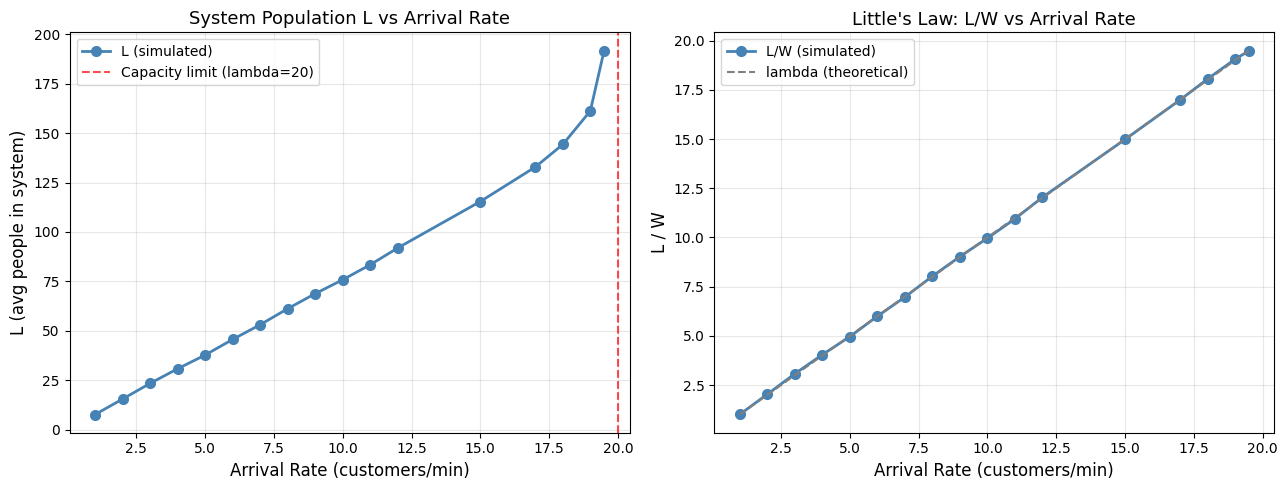

Saved: littles_law.png

TASK 2a: S vs lambda (n1=25, n3=10)
   lam |            S |   S approx lam? | Note
-----------------------------------------------------------------
     1 |       1.0074 |             Yes | S = lam: flow balance holds (stable)
     5 |       4.9596 |             Yes | S = lam: flow balance holds (stable)
    10 |       9.9574 |             Yes | S = lam: flow balance holds (stable)
    15 |      14.9819 |             Yes | S = lam: flow balance holds (stable)
    18 |      18.0511 |             Yes | S = lam: flow balance holds (stable)
    19 |      19.0670 |             Yes | S = lam: flow balance holds (stable)

At steady state, throughput S equals arrival rate lambda.
When unstable, S < lambda because the queue grows unboundedly.

TASK 2b: Optimize n3 (lambda=10, n1=25)
Cost = 1*L - 1*S + 10*n3
  n3 |          L |          W |          S |         Cost | Status
-----------------------------------------------------------------
   1 |   diverges |        --- 

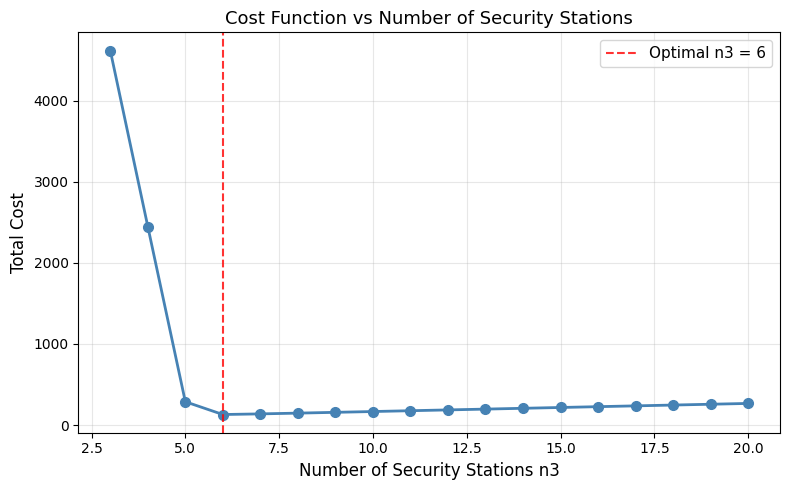

Saved: cost_vs_n3.png

Monte Carlo CI: baseline (lambda=10, n1=25, n3=10), 5 reps
L = 76.17 +/- 0.49
W = 7.62 +/- 0.00 min
S = 9.9984 +/- 0.0645

Monte Carlo CI: optimal n3=6, 5 reps
L = 79.22 +/- 0.89
W = 7.92 +/- 0.05 min
S = 9.9979 +/- 0.0645


In [ ]:
!pip install matplotlib numpy -q

import numpy as np
import heapq
import matplotlib.pyplot as plt

SEED = 42
MU1_LOG_MEAN = 0.1
MU1_LOG_STD  = 0.1
COMMUTE_MEAN = 6.0
COMMUTE_STD  = 1.0
MU3          = 2.0

def sample_service_checkin(rng):
    return rng.lognormal(MU1_LOG_MEAN, MU1_LOG_STD)

def sample_commute(rng):
    while True:
        v = rng.normal(COMMUTE_MEAN, COMMUTE_STD)
        if v > 0:
            return v

def sample_security(rng):
    return rng.exponential(1.0 / MU3)

def run_simulation(lam, n1=25, n3=10, sim_time=2000, warmup=200, seed=SEED):
    rng = np.random.default_rng(seed)
    heap = []
    cid  = 0

    def push(t, etype, c):
        heapq.heappush(heap, (t, etype, c))

    checkin_servers  = np.zeros(n1)
    security_servers = np.zeros(n3)
    entry_time = {}
    t_last       = 0.0
    weighted_L   = 0.0
    people_in    = 0
    completions  = 0
    total_W      = 0.0

    push(rng.exponential(1.0 / lam), 0, cid)
    cid += 1
    current_t = 0.0

    while heap:
        current_t, etype, customer = heapq.heappop(heap)
        if current_t > sim_time:
            break

        if current_t > warmup:
            dt = current_t - max(t_last, warmup)
            weighted_L += people_in * dt
        t_last = current_t

        if etype == 0:
            entry_time[customer] = current_t
            people_in += 1
            srv = int(np.argmin(checkin_servers))
            start = max(current_t, checkin_servers[srv])
            svc   = sample_service_checkin(rng)
            checkin_servers[srv] = start + svc
            push(start + svc, 1, customer)
            if current_t < sim_time:
                push(current_t + rng.exponential(1.0 / lam), 0, cid)
                cid += 1

        elif etype == 1:
            push(current_t + sample_commute(rng), 2, customer)

        elif etype == 2:
            srv = int(np.argmin(security_servers))
            start = max(current_t, security_servers[srv])
            svc   = sample_security(rng)
            security_servers[srv] = start + svc
            push(start + svc, 3, customer)

        elif etype == 3:
            people_in -= 1
            if current_t > warmup and customer in entry_time:
                total_W  += current_t - entry_time[customer]
                completions += 1

    effective_time = sim_time - warmup
    L = weighted_L / effective_time if effective_time > 0 else np.inf
    W = total_W / completions       if completions > 0    else np.inf
    S = completions / effective_time if effective_time > 0 else 0.0
    return L, W, S

def run_monte_carlo(lam, n1=25, n3=10, sim_time=2000, warmup=200, n_rep=5):
    Ls, Ws, Ss = [], [], []
    for rep in range(n_rep):
        L, W, S = run_simulation(lam, n1, n3, sim_time, warmup, seed=SEED + rep)
        Ls.append(L); Ws.append(W); Ss.append(S)
    def stats(arr):
        a = np.array(arr)
        return a.mean(), 1.96 * a.std(ddof=1) / np.sqrt(len(a))
    return stats(Ls), stats(Ws), stats(Ss)


# ================================================================
# TASK 1: L/W vs lambda
# ================================================================
lambdas_stable = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
lambdas_boundary = [15, 17, 18, 19, 19.5]
lambdas_all = lambdas_stable + lambdas_boundary

print("=" * 65)
print("TASK 1: L, W, L/W across arrival rates (n1=25, n3=10)")
print("=" * 65)
print(f"{'lam':>6} | {'L':>10} | {'W':>10} | {'L/W':>10} | {'Status'}")
print("-" * 55)

L_vals, W_vals, LW_vals, lam_plot = [], [], [], []

for lam in lambdas_all:
    L, W, S = run_simulation(lam, n1=25, n3=10, sim_time=3000, warmup=300)
    stable = L < 5000
    lw = L/W if (W > 0 and W < 1e6) else float('nan')
    status = "stable" if stable else "UNSTABLE"
    print(f"{lam:>6} | {L:>10.2f} | {W:>10.2f} | {lw:>10.3f} | {status}")
    if stable:
        L_vals.append(L)
        W_vals.append(W)
        LW_vals.append(lw)
        lam_plot.append(lam)

print("\nConclusion: L/W ~ lambda => Little's Law L = lambda * W verified.")


# ================================================================
# TASK 1 PLOTS
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lam_plot, L_vals, 'o-', color='steelblue', lw=2, ms=7, label='L (simulated)')
axes[0].set_xlabel('Arrival Rate (customers/min)', fontsize=12)
axes[0].set_ylabel('L (avg people in system)', fontsize=12)
axes[0].set_title('System Population L vs Arrival Rate', fontsize=13)
axes[0].axvline(x=20, color='red', ls='--', alpha=0.7, label='Capacity limit (lambda=20)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(lam_plot, LW_vals, 'o-', color='steelblue', lw=2, ms=7, label='L/W (simulated)')
axes[1].plot(lam_plot, lam_plot, '--', color='gray', lw=1.5, label='lambda (theoretical)')
axes[1].set_xlabel('Arrival Rate (customers/min)', fontsize=12)
axes[1].set_ylabel('L / W', fontsize=12)
axes[1].set_title("Little's Law: L/W vs Arrival Rate", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('littles_law.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: littles_law.png")


# ================================================================
# TASK 2: S vs lambda
# ================================================================
print("\n" + "=" * 65)
print("TASK 2a: S vs lambda (n1=25, n3=10)")
print("=" * 65)
print(f"{'lam':>6} | {'S':>12} | {'S approx lam?':>15} | Note")
print("-" * 65)

for lam in [1, 5, 10, 15, 18, 19]:
    L, W, S = run_simulation(lam, n1=25, n3=10, sim_time=3000, warmup=300)
    stable = L < 5000
    approx = stable and abs(S - lam) / lam < 0.02
    note = "S = lam: flow balance holds (stable)" if approx else \
           "S < lam: arrivals exceed capacity (unstable)"
    print(f"{lam:>6} | {S:>12.4f} | {'Yes' if approx else 'No':>15} | {note}")

print("\nAt steady state, throughput S equals arrival rate lambda.")
print("When unstable, S < lambda because the queue grows unboundedly.")


# ================================================================
# TASK 2: Optimize n3
# ================================================================
print("\n" + "=" * 65)
print("TASK 2b: Optimize n3 (lambda=10, n1=25)")
print("Cost = 1*L - 1*S + 10*n3")
print("=" * 65)
print(f"{'n3':>4} | {'L':>10} | {'W':>10} | {'S':>10} | {'Cost':>12} | Status")
print("-" * 65)

n3_range  = list(range(1, 21))
L_n3_list, W_n3_list, S_n3_list, cost_list = [], [], [], []
best_cost, best_n3 = np.inf, None

for n3 in n3_range:
    L, W, S = run_simulation(10, n1=25, n3=n3, sim_time=2000, warmup=200)
    stable = L < 5000
    cost   = (1*L - 1*S + 10*n3) if stable else np.inf
    L_n3_list.append(L if stable else None)
    W_n3_list.append(W if (stable and W < 1e6) else None)
    S_n3_list.append(S if stable else None)
    cost_list.append(cost if stable else None)
    status = "stable" if stable else "UNSTABLE"
    L_str  = f"{L:.2f}"   if stable else "diverges"
    W_str  = f"{W:.2f}"   if (stable and W < 1e6) else "---"
    S_str  = f"{S:.4f}"   if stable else "---"
    c_str  = f"{cost:.2f}" if stable else "inf"
    print(f"{n3:>4} | {L_str:>10} | {W_str:>10} | {S_str:>10} | {c_str:>12} | {status}")
    if cost < best_cost:
        best_cost = cost
        best_n3   = n3

print(f"\nOptimal n3 = {best_n3}, minimum cost = {best_cost:.2f}")


# ================================================================
# TASK 2 PLOT: Cost vs n3
# ================================================================
n3_stable   = [n for n, c in zip(n3_range, cost_list) if c is not None]
cost_stable = [c for c in cost_list if c is not None]

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(n3_stable, cost_stable, 'o-', color='steelblue', lw=2, ms=7)
ax2.axvline(x=best_n3, color='red', ls='--', alpha=0.8,
            label=f'Optimal n3 = {best_n3}')
ax2.set_xlabel('Number of Security Stations n3', fontsize=12)
ax2.set_ylabel('Total Cost', fontsize=12)
ax2.set_title('Cost Function vs Number of Security Stations', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cost_vs_n3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cost_vs_n3.png")


# ================================================================
# Monte Carlo CI for baseline
# ================================================================
print("\n" + "=" * 65)
print("Monte Carlo CI: baseline (lambda=10, n1=25, n3=10), 5 reps")
print("=" * 65)
(Lm, Lci), (Wm, Wci), (Sm, Sci) = run_monte_carlo(lam=10, n3=10, n_rep=5)
print(f"L = {Lm:.2f} +/- {Lci:.2f}")
print(f"W = {Wm:.2f} +/- {Wci:.2f} min")
print(f"S = {Sm:.4f} +/- {Sci:.4f}")

print("\n" + "=" * 65)
print(f"Monte Carlo CI: optimal n3={best_n3}, 5 reps")
print("=" * 65)
(Lm2, Lci2), (Wm2, Wci2), (Sm2, Sci2) = run_monte_carlo(lam=10, n3=best_n3, n_rep=5)
print(f"L = {Lm2:.2f} +/- {Lci2:.2f}")
print(f"W = {Wm2:.2f} +/- {Wci2:.2f} min")
print(f"S = {Sm2:.4f} +/- {Sci2:.4f}")

## Part 3: Optimization of Cargo Fleet Operations


In [ ]:
!pip install pulp -q

import pulp
import pandas as pd

# ============================================================
# 1. DATA
# ============================================================

airports = ['A', 'B', 'C']
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
routes = [(i, j) for i in airports for j in airports if i != j]

demand = {
    ('A','B'): {'Mon':100, 'Tue':200, 'Wed':100, 'Thu':400, 'Fri':300},
    ('A','C'): {'Mon': 50, 'Tue': 50, 'Wed': 50,  'Thu': 50, 'Fri': 50},
    ('B','A'): {'Mon': 25, 'Tue': 25, 'Wed': 25,  'Thu': 25, 'Fri': 25},
    ('B','C'): {'Mon': 25, 'Tue': 25, 'Wed': 25,  'Thu': 25, 'Fri': 25},
    ('C','A'): {'Mon': 40, 'Tue': 40, 'Wed': 40,  'Thu': 40, 'Fri': 40},
    ('C','B'): {'Mon':400, 'Tue':200, 'Wed':300,  'Thu':200, 'Fri':400},
}

repo_cost = {
    ('A','B'): 6, ('B','A'): 6,
    ('A','C'): 7, ('C','A'): 7,
    ('B','C'): 3, ('C','B'): 3,
}

FLEET = 1200
HOLDING_COST = 10
day_next = {'Mon':'Tue', 'Tue':'Wed', 'Wed':'Thu', 'Thu':'Fri', 'Fri':'Mon'}

# ============================================================
# 2. MODEL
# ============================================================

model = pulp.LpProblem("ExpressAir_Cargo", pulp.LpMinimize)

x = {(i,j,t): pulp.LpVariable(f"x_{i}{j}_{t}", lowBound=0, cat='Integer')
     for (i,j) in routes for t in days}

e = {(i,j,t): pulp.LpVariable(f"e_{i}{j}_{t}", lowBound=0, cat='Integer')
     for (i,j) in routes for t in days}

s = {(i,t): pulp.LpVariable(f"s_{i}_{t}", lowBound=0, cat='Integer')
     for i in airports for t in days}

g = {(i,j,t): pulp.LpVariable(f"g_{i}{j}_{t}", lowBound=0, cat='Integer')
     for (i,j) in routes for t in days}

a = {(i,t): pulp.LpVariable(f"a_{i}_{t}", lowBound=0, cat='Integer')
     for i in airports for t in days}

# --- Objective ---
model += (
    pulp.lpSum(repo_cost[i,j] * e[i,j,t] for (i,j) in routes for t in days) +
    HOLDING_COST * pulp.lpSum(g[i,j,t] for (i,j) in routes for t in days)
), "Total_Cost"

# --- Constraints ---
for t in days:
    t_next = day_next[t]

    for i in airports:
        # Aircraft dispatch balance
        model += (
            pulp.lpSum(x[i,j,t] + e[i,j,t] for j in airports if j != i) + s[i,t]
            == a[i,t]
        ), f"dispatch_balance_{i}_{t}"

        # Aircraft arrival balance
        model += (
            a[i,t_next]
            == s[i,t] + pulp.lpSum(x[j,i,t] + e[j,i,t] for j in airports if j != i)
        ), f"arrival_balance_{i}_{t}"

    # Fleet conservation
    model += (
        pulp.lpSum(a[i,t] for i in airports) == FLEET
    ), f"fleet_{t}"

for (i,j) in routes:
    for t in days:
        t_next = day_next[t]

        # Cargo flow balance
        model += (
            g[i,j,t_next] == g[i,j,t] + demand[i,j][t] - x[i,j,t]
        ), f"cargo_balance_{i}{j}_{t}"

        # x cannot exceed available aircraft at origin
        # NOTE: x <= g constraint removed per instructor feedback
        # (redundant and over-constraining; g >= 0 already enforces feasibility)
        model += x[i,j,t] <= a[i,t], f"aircraft_cap_{i}{j}_{t}"

# ============================================================
# 3. SOLVE
# ============================================================

solver = pulp.PULP_CBC_CMD(msg=1)
model.solve(solver)

print("\n" + "="*50)
print(f"Status: {pulp.LpStatus[model.status]}")
print(f"Total Cost: {pulp.value(model.objective):,.1f}")
print("="*50)

# ============================================================
# 4. RESULTS
# ============================================================

print("\n--- Aircraft Available (a[i,t]) ---")
avail_data = {i: {t: int(pulp.value(a[i,t])) for t in days} for i in airports}
df_avail = pd.DataFrame(avail_data, index=days).T
df_avail.index.name = "Airport"
print(df_avail)

print("\n--- Loaded Movements (x[i,j,t]) ---")
rows = []
for (i,j) in routes:
    row = {'Route': f"{i}>{j}"}
    for t in days:
        row[t] = int(pulp.value(x[i,j,t]))
    rows.append(row)
df_x = pd.DataFrame(rows).set_index('Route')
print(df_x)

print("\n--- Empty Repositioning (e[i,j,t]) ---")
rows = []
for (i,j) in routes:
    vals = {t: int(pulp.value(e[i,j,t])) for t in days}
    if any(v > 0 for v in vals.values()):
        row = {'Route': f"{i}>{j}"}
        row.update(vals)
        rows.append(row)
if rows:
    df_e = pd.DataFrame(rows).set_index('Route')
    print(df_e)
else:
    print("No empty repositioning movements.")

print("\n--- Cargo Backlog (g[i,j,t]) ---")
rows = []
for (i,j) in routes:
    vals = {t: int(pulp.value(g[i,j,t])) for t in days}
    if any(v > 0 for v in vals.values()):
        row = {'Route': f"{i}>{j}"}
        row.update(vals)
        rows.append(row)
if rows:
    df_g = pd.DataFrame(rows).set_index('Route')
    print(df_g)
else:
    print("No cargo backlog.")

total_repo = sum(repo_cost[i,j] * pulp.value(e[i,j,t])
                 for (i,j) in routes for t in days)
total_hold = HOLDING_COST * sum(pulp.value(g[i,j,t])
                                for (i,j) in routes for t in days)
print(f"\n--- Cost Breakdown ---")
print(f"Empty repositioning cost : {total_repo:,.1f}")
print(f"Cargo holding cost       : {total_hold:,.1f}")
print(f"Total                    : {total_repo + total_hold:,.1f}")

# ============================================================
# 5. SENSITIVITY: Fleet size
# ============================================================

print("\n--- Sensitivity: Fleet Size vs Total Cost ---")

fleet_results = []
for fleet_size in [1000, 1100, 1200, 1300, 1400]:
    m2 = pulp.LpProblem(f"ExpressAir_{fleet_size}", pulp.LpMinimize)

    x2 = {(i,j,t): pulp.LpVariable(f"x_{i}{j}_{t}", lowBound=0, cat='Integer')
          for (i,j) in routes for t in days}
    e2 = {(i,j,t): pulp.LpVariable(f"e_{i}{j}_{t}", lowBound=0, cat='Integer')
          for (i,j) in routes for t in days}
    s2 = {(i,t): pulp.LpVariable(f"s_{i}_{t}", lowBound=0, cat='Integer')
          for i in airports for t in days}
    g2 = {(i,j,t): pulp.LpVariable(f"g_{i}{j}_{t}", lowBound=0, cat='Integer')
          for (i,j) in routes for t in days}
    a2 = {(i,t): pulp.LpVariable(f"a_{i}_{t}", lowBound=0, cat='Integer')
          for i in airports for t in days}

    m2 += (
        pulp.lpSum(repo_cost[i,j] * e2[i,j,t] for (i,j) in routes for t in days) +
        HOLDING_COST * pulp.lpSum(g2[i,j,t] for (i,j) in routes for t in days)
    )

    for t in days:
        t_next = day_next[t]
        for i in airports:
            m2 += (pulp.lpSum(x2[i,j,t] + e2[i,j,t] for j in airports if j != i)
                   + s2[i,t] == a2[i,t])
            m2 += (a2[i,t_next] == s2[i,t]
                   + pulp.lpSum(x2[j,i,t] + e2[j,i,t] for j in airports if j != i))
        m2 += pulp.lpSum(a2[i,t] for i in airports) == fleet_size

    for (i,j) in routes:
        for t in days:
            t_next = day_next[t]
            m2 += g2[i,j,t_next] == g2[i,j,t] + demand[i,j][t] - x2[i,j,t]
            m2 += x2[i,j,t] <= a2[i,t]

    m2.solve(pulp.PULP_CBC_CMD(msg=0))
    status = pulp.LpStatus[m2.status]
    cost = round(pulp.value(m2.objective), 1) if m2.status == 1 else 'Infeasible'
    fleet_results.append({'Fleet Size': fleet_size, 'Status': status, 'Total Cost': cost})

df_fleet = pd.DataFrame(fleet_results)
print(df_fleet.to_string(index=False))


Status: Optimal
Total Cost: 12,925.0

--- Aircraft Available (a[i,t]) ---
         Mon  Tue  Wed  Thu  Fri
Airport                         
A        150  270  150  450  350
B        510  600  490  400  600
C        540  330  560  350  250

--- Loaded Movements (x[i,j,t]) ---
       Mon  Tue  Wed  Thu  Fri
Route                         
A>B    100  200  100  400  300
A>C     50   50   50   50   50
B>A     25   25   25   25   25
B>C     25   25   25   25   25
C>A     40   40   40   40   40
C>B    500  290  300  200  210

--- Empty Repositioning (e[i,j,t]) ---
       Mon  Tue  Wed  Thu  Fri
Route                         
B>A    205   65  385  285   85
B>C    255  485   55   65  465

--- Cargo Backlog (g[i,j,t]) ---
       Mon  Tue  Wed  Thu  Fri
Route                         
C>B    190   90    0    0    0

--- Cost Breakdown ---
Empty repositioning cost : 10,125.0
Cargo holding cost       : 2,800.0
Total                    : 12,925.0

--- Sensitivity: Fleet Size vs Total Cost ---
 Fleet

## Part 4 Analysis of aviation accidents


In [ ]:
"""
Part 4: Analysis of U.S. Civil Aviation Accidents (1982–2022)
Updated version:
- Regression output: UninjuredRate
- Classification output: FatalAccident
- Add Aircraft Damage features to improve explanatory power
"""

import os
import numpy as np
import pandas as pd
import warnings

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

warnings.filterwarnings("ignore")

# =========================
# STEP 0 — LOAD DATA
# =========================

CSV_FILE = "aviation_accident.csv"

if not os.path.exists(CSV_FILE):
    raise FileNotFoundError("aviation_accident.csv not found. Put it in the same folder as this notebook.")

df_raw = pd.read_csv(CSV_FILE, low_memory=False)
print(f"Raw data loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

# =========================
# STEP 1 — CLEAN DATA
# =========================

df = df_raw[df_raw["Country"] == "United States"].copy()
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df[df["Year"].between(1982, 2022)].copy()

injury_cols = [
    "Total.Fatal.Injuries",
    "Total.Serious.Injuries",
    "Total.Minor.Injuries",
    "Total.Uninjured"
]

for col in injury_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["TotalOccupants"] = (
    df["Total.Fatal.Injuries"]
    + df["Total.Serious.Injuries"]
    + df["Total.Minor.Injuries"]
    + df["Total.Uninjured"]
)

df["UninjuredRate"] = np.where(
    df["TotalOccupants"] > 0,
    df["Total.Uninjured"] / df["TotalOccupants"],
    np.nan
)

df["FatalAccident"] = (df["Total.Fatal.Injuries"] > 0).astype(int)

df["Weekend"] = df["Weekend"].astype(str).str.strip().str.upper().eq("TRUE").astype(int)
df["Weather.Condition"] = df["Weather.Condition"].replace("nan", np.nan)
df["Broad.phase.of.flight"] = df["Broad.phase.of.flight"].replace("nan", np.nan)
df["Aircraft.damage"] = df["Aircraft.damage"].astype(str).str.strip()

df.reset_index(drop=True, inplace=True)

print(f"After filtering (US, 1982–2022): {len(df):,} records")

# =========================
# STEP 2 — DESCRIPTIVE ANALYSIS
# =========================

print("\n" + "=" * 70)
print("DESCRIPTIVE ANALYSIS")
print("=" * 70)

accidents_per_year = df.groupby("Year").size()

print("\n[ Accidents per Year ]")
print(accidents_per_year.to_string())

pct_decline = (1 - accidents_per_year.loc[2022] / accidents_per_year.loc[1982]) * 100

print(f"\nPeak year: {accidents_per_year.idxmax():.0f} ({accidents_per_year.max():,} accidents)")
print(f"Lowest year after 2008: {accidents_per_year[accidents_per_year.index >= 2008].idxmin():.0f} "
      f"({accidents_per_year[accidents_per_year.index >= 2008].min():,} accidents)")
print(f"Decline 1982→2022: {pct_decline:.1f}%")

uninjured_by_year = df.groupby("Year")["UninjuredRate"].mean()

print("\n[ Average Uninjured Rate by Year ]")
print(uninjured_by_year.round(3).to_string())

print(f"\nOverall average uninjured rate: {df['UninjuredRate'].mean():.3f}")
print(f"1982–1990 average: {df[df['Year'] <= 1990]['UninjuredRate'].mean():.3f}")
print(f"2015–2022 average: {df[df['Year'] >= 2015]['UninjuredRate'].mean():.3f}")

phase_counts = df["Broad.phase.of.flight"].dropna().value_counts()

print("\n[ Phase of Flight: Top 10 ]")
print(phase_counts.head(10).to_string())

weather_counts = df["Weather.Condition"].dropna().value_counts()

print("\n[ Weather Condition ]")
print(weather_counts.to_string())

print("\n[ Fatal Accident Rate by Weather ]")
for weather in ["VMC", "IMC"]:
    mask = df["Weather.Condition"] == weather
    fatal_rate = df.loc[mask, "FatalAccident"].mean() * 100
    n = mask.sum()
    print(f"{weather}: {fatal_rate:.1f}% fatal (n={n:,})")

print("\n[ Aircraft Damage ]")
print(df["Aircraft.damage"].value_counts().to_string())

fatal_by_year = df.groupby("Year")["FatalAccident"].mean()

print("\n[ Fatal Accident Rate by Year ]")
print(fatal_by_year.round(3).to_string())

# =========================
# STEP 3 — FEATURE ENGINEERING
# =========================

# Keep anomalous years in descriptive analysis, but exclude 2001–2007 from modeling
df2 = df[
    (~df["Year"].between(2001, 2007)) &
    (df["UninjuredRate"].notna())
].copy()

df2["IMC"] = (df2["Weather.Condition"] == "IMC").astype(int)
df2["IsWeekend"] = df2["Weekend"].astype(int)
df2["YearNorm"] = (df2["Year"] - 1982) / 40.0

df2["IsLanding"] = (df2["Broad.phase.of.flight"] == "Landing").astype(int)
df2["IsTakeoff"] = (df2["Broad.phase.of.flight"] == "Takeoff").astype(int)
df2["IsCruise"] = (df2["Broad.phase.of.flight"] == "Cruise").astype(int)
df2["IsApproach"] = (df2["Broad.phase.of.flight"] == "Approach").astype(int)
df2["IsManeuvering"] = (df2["Broad.phase.of.flight"] == "Maneuvering").astype(int)

df2["MultiEngine"] = (
    pd.to_numeric(df2["Number.of.Engines"], errors="coerce").fillna(1) > 1
).astype(int)

# Aircraft damage features — added to improve severity prediction
df2["DamageDestroyed"] = (df2["Aircraft.damage"] == "Destroyed").astype(int)
df2["DamageSubstantial"] = (df2["Aircraft.damage"] == "Substantial").astype(int)
df2["DamageMinor"] = (df2["Aircraft.damage"] == "Minor").astype(int)

# Interaction features
df2["IMC_Maneuvering"] = df2["IMC"] * df2["IsManeuvering"]
df2["IMC_Landing"] = df2["IMC"] * df2["IsLanding"]

FEATURES = [
    "YearNorm",
    "IsWeekend",
    "IMC",
    "IsLanding",
    "IsTakeoff",
    "IsCruise",
    "IsApproach",
    "IsManeuvering",
    "MultiEngine",
    "DamageDestroyed",
    "DamageSubstantial",
    "DamageMinor",
    "IMC_Maneuvering",
    "IMC_Landing"
]

X = df2[FEATURES].fillna(0)

# =========================
# STEP 4A — REGRESSION
# =========================

print("\n" + "=" * 70)
print("REGRESSION ANALYSIS — Predict Uninjured Rate")
print("=" * 70)

y_reg = df2["UninjuredRate"]

print(f"\nSamples: {len(y_reg):,}, Features: {len(FEATURES)}")

ridge = Ridge(alpha=1.0)
cv_ridge = cross_val_score(ridge, X, y_reg, cv=5, scoring="r2")

print("\n[ Ridge Regression: 5-fold CV ]")
print(f"R2 per fold: {np.round(cv_ridge, 4)}")
print(f"Mean R2: {cv_ridge.mean():.4f} +/- {cv_ridge.std():.4f}")

ridge.fit(X, y_reg)
ridge_coef = pd.Series(ridge.coef_, index=FEATURES).sort_values()

print("\nRidge coefficients:")
for feat, val in ridge_coef.items():
    print(f"{feat:22} : {val:+.4f}")

gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

cv_gb_reg = cross_val_score(gb_reg, X, y_reg, cv=5, scoring="r2")

print("\n[ Gradient Boosting Regression: 5-fold CV ]")
print(f"R2 per fold: {np.round(cv_gb_reg, 4)}")
print(f"Mean R2: {cv_gb_reg.mean():.4f} +/- {cv_gb_reg.std():.4f}")

gb_reg.fit(X, y_reg)
gb_reg_imp = pd.Series(gb_reg.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\nGradient Boosting regression feature importances:")
print("(Importance shows relative predictive contribution, not positive/negative direction.)")
for feat, val in gb_reg_imp.items():
    print(f"{feat:22} : {val:.4f}")

# =========================
# STEP 4B — CLASSIFICATION
# =========================

print("\n" + "=" * 70)
print("CLASSIFICATION ANALYSIS — Predict Fatal vs. Non-Fatal Accident")
print("=" * 70)

y_cls = df2["FatalAccident"]

print(f"\nFatal accident share: {y_cls.mean() * 100:.1f}%")
print(f"Non-fatal accident share: {(1 - y_cls.mean()) * 100:.1f}%")

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

gb_cls = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1"
}

for name, model in [
    ("Logistic Regression", logit),
    ("Gradient Boosting Classifier", gb_cls)
]:
    scores = cross_validate(model, X, y_cls, cv=cv_cls, scoring=scoring)

    print(f"\n[ {name}: 5-fold CV ]")
    print(f"ROC-AUC           : {scores['test_roc_auc'].mean():.4f}")
    print(f"Accuracy          : {scores['test_accuracy'].mean():.4f}")
    print(f"Balanced Accuracy : {scores['test_balanced_accuracy'].mean():.4f}")
    print(f"F1 Score          : {scores['test_f1'].mean():.4f}")

logit.fit(X, y_cls)
logit_coef = pd.Series(logit.coef_[0], index=FEATURES).sort_values()

print("\nLogistic Regression coefficients:")
print("(Positive coefficient means higher probability of fatal accident.)")
for feat, val in logit_coef.items():
    print(f"{feat:22} : {val:+.4f}")

gb_cls.fit(X, y_cls)
gb_cls_imp = pd.Series(gb_cls.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\nGradient Boosting classification feature importances:")
print("(Importance shows relative predictive contribution, not positive/negative direction.)")
for feat, val in gb_cls_imp.items():
    print(f"{feat:22} : {val:.4f}")

# =========================
# STEP 5 — SUMMARY
# =========================

print("\n" + "=" * 70)
print("KEY STATISTICS SUMMARY")
print("=" * 70)

print(f"Total US records (1982–2022): {len(df):,}")
print(f"Modeling records after excluding 2001–2007: {len(df2):,}")
print(f"Decline 1982→2022: {pct_decline:.1f}%")
print(f"Overall average uninjured rate: {df['UninjuredRate'].mean():.3f}")
print(f"Fatal accident share: {df['FatalAccident'].mean() * 100:.1f}%")
print(f"IMC share of accidents: {df['Weather.Condition'].eq('IMC').mean() * 100:.1f}%")
print(f"Fatal rate in IMC: {df[df['Weather.Condition'] == 'IMC']['FatalAccident'].mean() * 100:.1f}%")
print(f"Fatal rate in VMC: {df[df['Weather.Condition'] == 'VMC']['FatalAccident'].mean() * 100:.1f}%")
print(f"Most common recorded phase: {phase_counts.index[0]} ({phase_counts.iloc[0]:,})")
print(f"Ridge regression R2: {cv_ridge.mean():.4f}")
print(f"Gradient Boosting regression R2: {cv_gb_reg.mean():.4f}")

Raw data loaded: 68,565 rows, 31 columns
After filtering (US, 1982–2022): 65,691 records

DESCRIPTIVE ANALYSIS

[ Accidents per Year ]
Year
1982.0    3418
1983.0    3372
1984.0    3273
1985.0    2952
1986.0    2745
1987.0    2650
1988.0    2520
1989.0    2395
1990.0    2382
1991.0    2327
1992.0    2223
1993.0    2159
1994.0    2119
1995.0    2146
1996.0    2039
1997.0    1951
1998.0    2018
1999.0    2009
2000.0    1903
2001.0       3
2002.0       1
2003.0       2
2005.0       4
2006.0       3
2007.0      90
2008.0    1622
2009.0    1549
2010.0    1490
2011.0    1530
2012.0    1471
2013.0    1180
2014.0    1142
2015.0    1219
2016.0    1240
2017.0    1186
2018.0    1134
2019.0    1153
2020.0     973
2021.0    1061
2022.0    1037

Peak year: 1982 (3,418 accidents)
Lowest year after 2008: 2020 (973 accidents)
Decline 1982→2022: 69.7%

[ Average Uninjured Rate by Year ]
Year
1982.0    0.615
1983.0    0.596
1984.0    0.579
1985.0    0.593
1986.0    0.575
1987.0    0.601
1988.0    0.555
19